In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/02_nav_history.csv")

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [2]:
var_results = []

for code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    if len(returns) > 30:

        var_95 = np.percentile(
            returns,
            5
        )

        var_results.append({
            'amfi_code': code,
            'VaR_95': var_95
        })

var_df = pd.DataFrame(var_results)

var_df.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [3]:
var_df.to_csv(
    "../reports/var_analysis.csv",
    index=False
)

print("var_analysis.csv saved")

var_analysis.csv saved


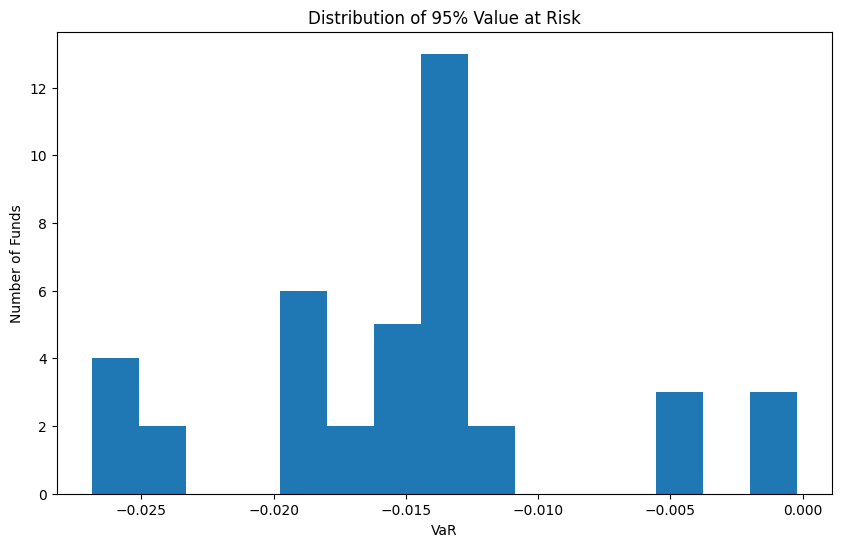

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    var_df['VaR_95'],
    bins=15
)

plt.title("Distribution of 95% Value at Risk")
plt.xlabel("VaR")
plt.ylabel("Number of Funds")

plt.show()

In [8]:
transactions = pd.read_csv(
    "../data/processed/08_investor_transactions.csv"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [9]:
cohort = transactions.groupby(
    'age_group'
).agg(
    investors=('investor_id', 'nunique'),
    total_investment=('amount_inr', 'sum'),
    avg_investment=('amount_inr', 'mean')
).reset_index()

cohort

,age_group,investors,total_investment,avg_investment
0,18-25,753,531639392,108144.709520
1,26-35,2033,1451600218,107821.452722
2,36-45,1237,871647528,107003.133808
3,46-55,589,405406469,107278.769251
4,56+,388,261286823,105613.105497


In [10]:
cohort.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv saved")

cohort_analysis.csv saved


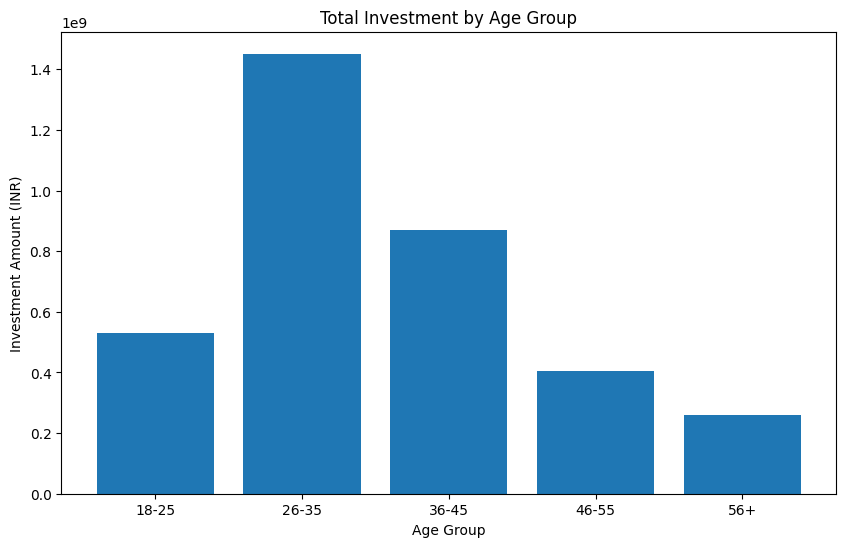

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    cohort['age_group'],
    cohort['total_investment']
)

plt.title("Total Investment by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.show()

In [12]:
fund_scorecard = pd.read_csv(
    "../reports/fund_scorecard.csv"
)

top_funds = fund_scorecard.sort_values(
    'fund_score',
    ascending=False
)[[
    'scheme_name',
    'fund_score'
]].head(10)

top_funds

,scheme_name,fund_score
34,Mirae Asset Large Cap Fund - Regular - Growth,100.000000
25,ICICI Pru Midcap Fund - Regular - Growth,94.439618
30,Kotak Flexicap Fund - Regular - Growth,94.092094
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,92.354474
24,ICICI Pru Bluechip Fund - Direct - Growth,91.311903
16,Axis Midcap Fund - Regular - Growth,87.141616
19,SBI Bluechip Fund - Regular Plan - Growth,84.100782
36,Mirae Asset Tax Saver Fund - Regular - Growth,82.536924
3,ABSL Frontline Equity Fund - Regular - Growth,74.891399
21,SBI Small Cap Fund - Regular Plan - Growth,73.761946


In [13]:
top_funds.to_csv(
    "../reports/recommended_funds.csv",
    index=False
)

print("recommended_funds.csv saved")

recommended_funds.csv saved


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/02_nav_history.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings.csv")
fund_master = pd.read_csv("../data/processed/01_fund_master.csv")

print(nav.shape)
print(transactions.shape)
print(holdings.shape)

(46000, 3)
(32778, 13)
(322, 8)


In [2]:
print(nav.columns)
print(transactions.columns)
print(holdings.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [3]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [4]:
results = []

for fund, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    if len(returns) > 30:

        var95 = np.percentile(returns, 5)

        cvar95 = returns[returns <= var95].mean()

        results.append([
            fund,
            var95,
            cvar95
        ])

var_cvar = pd.DataFrame(
    results,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved")

var_cvar_report.csv saved


In [6]:
var_cvar.sort_values(
    'VaR_95'
).head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [7]:
rolling_sharpe_data = []

for fund, group in nav.groupby('amfi_code'):

    group = group.sort_values('date').copy()

    group['rolling_sharpe'] = (
        group['daily_return'].rolling(90).mean()
        /
        group['daily_return'].rolling(90).std()
    ) * np.sqrt(252)

    rolling_sharpe_data.append(group)

rolling_sharpe_df = pd.concat(
    rolling_sharpe_data,
    ignore_index=True
)

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [8]:
top5 = (
    var_cvar
    .sort_values('CVaR_95')
    .head(5)
    ['amfi_code']
    .tolist()
)

top5

[101207, 119599, 118634, 119095, 149324]

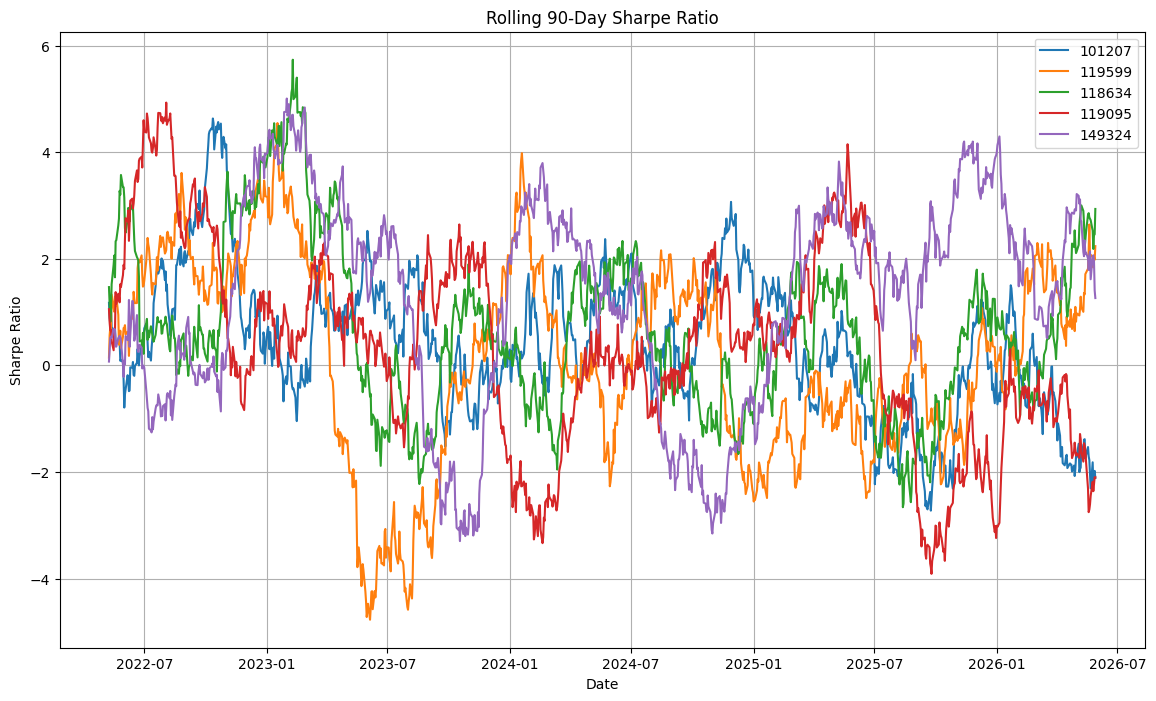

In [9]:
plt.figure(figsize=(14,8))

for fund in top5:

    df = rolling_sharpe_df[
        rolling_sharpe_df['amfi_code'] == fund
    ]

    plt.plot(
        df['date'],
        df['rolling_sharpe'],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.show()

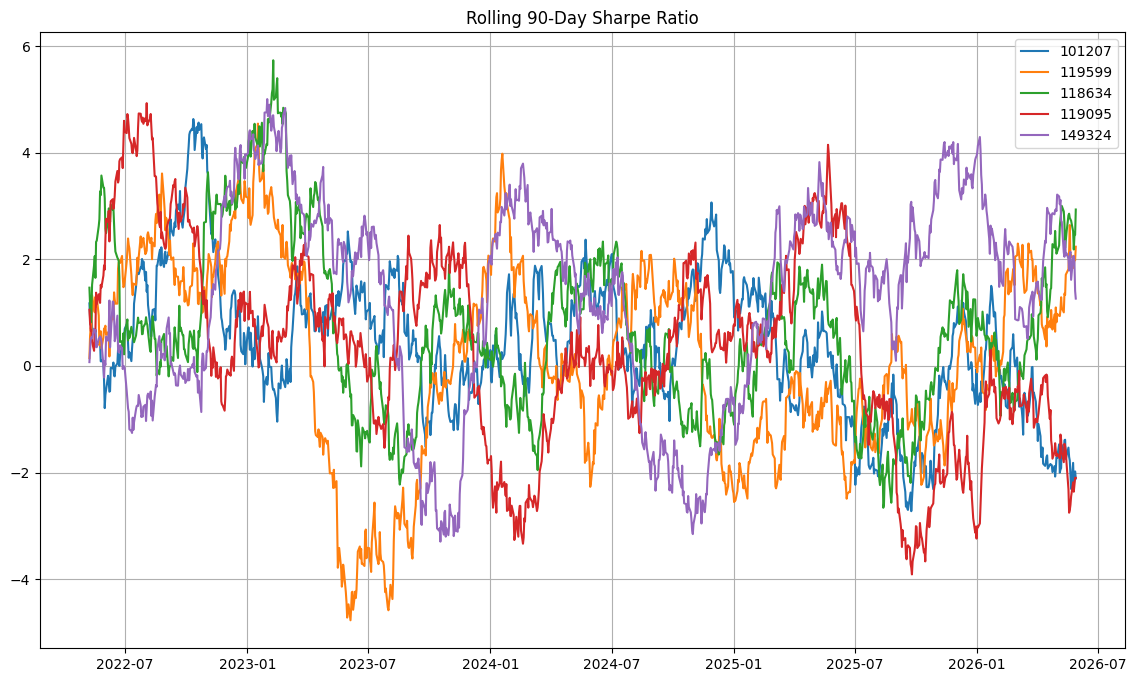

rolling_sharpe_chart.png saved


In [10]:
plt.figure(figsize=(14,8))

for fund in top5:

    df = rolling_sharpe_df[
        rolling_sharpe_df['amfi_code'] == fund
    ]

    plt.plot(
        df['date'],
        df['rolling_sharpe'],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

print("rolling_sharpe_chart.png saved")

In [11]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [12]:
first_txn = (
    transactions
    .groupby('investor_id')['transaction_date']
    .min()
    .reset_index()
)

first_txn['cohort_year'] = (
    first_txn['transaction_date']
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [13]:
transactions = transactions.merge(
    first_txn[['investor_id', 'cohort_year']],
    on='investor_id',
    how='left'
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [14]:
cohort_summary = (
    transactions
    .groupby('cohort_year')
    .agg(
        avg_investment=('amount_inr', 'mean'),
        total_investment=('amount_inr', 'sum'),
        investors=('investor_id', 'nunique')
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_investment,total_investment,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [15]:
top_fund = (
    transactions
    .groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='count')
)

top_fund = (
    top_fund
    .sort_values(
        ['cohort_year', 'count'],
        ascending=[True, False]
    )
    .groupby('cohort_year')
    .head(1)
)

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [16]:
cohort_summary.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv saved")

cohort_analysis.csv saved


In [17]:
sip_txns = transactions[
    transactions['transaction_type']
    .str.upper()
    .str.contains('SIP', na=False)
].copy()

sip_txns.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [18]:
sip_txns = sip_txns.sort_values(
    ['investor_id', 'transaction_date']
)

sip_txns.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [19]:
sip_txns['gap_days'] = (
    sip_txns.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

sip_txns.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0


In [20]:
sip_continuity = (
    sip_txns
    .groupby('investor_id')
    .agg(
        sip_count=('transaction_date', 'count'),
        avg_gap_days=('gap_days', 'mean')
    )
    .reset_index()
)

sip_continuity.head()

,investor_id,sip_count,avg_gap_days
0,INV000001,2,76.0
1,INV000002,3,207.0
2,INV000003,2,238.0
3,INV000004,6,85.4
4,INV000005,3,14.0


In [21]:
sip_continuity = sip_continuity[
    sip_continuity['sip_count'] >= 6
]

sip_continuity.head()

,investor_id,sip_count,avg_gap_days
3,INV000004,6,85.400000
7,INV000008,6,70.400000
9,INV000010,6,64.800000
10,INV000011,7,40.166667
11,INV000012,8,57.000000


In [22]:
sip_continuity['status'] = np.where(
    sip_continuity['avg_gap_days'] > 35,
    'At-Risk',
    'Active'
)

sip_continuity.head()

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


In [23]:
sip_continuity['status'].value_counts()

status
At-Risk    1332
Active       30
Name: count, dtype: int64

In [24]:
sip_continuity.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print("sip_continuity_report.csv saved")

sip_continuity_report.csv saved


In [25]:
sharpe = pd.read_csv("../reports/sharpe_ratio.csv")

sharpe.head()

,amfi_code,scheme_name,sharpe_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.567095
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027213
4,101207,ABSL Small Cap Fund - Regular - Growth,0.162661


In [26]:
sharpe['risk_grade'] = pd.qcut(
    sharpe['sharpe_ratio'],
    q=3,
    labels=['Low', 'Moderate', 'High']
)

sharpe.head()

,amfi_code,scheme_name,sharpe_ratio,risk_grade
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517,Low
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.567095,Low
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,High
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027213,High
4,101207,ABSL Small Cap Fund - Regular - Growth,0.162661,Low


In [27]:
def recommend_funds(risk_appetite):

    recommendations = (
        sharpe[
            sharpe['risk_grade'] == risk_appetite
        ]
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        ['amfi_code', 'sharpe_ratio', 'risk_grade']
    ]

In [28]:
recommend_funds('Moderate')

,amfi_code,sharpe_ratio,risk_grade
35,148568,0.926287,Moderate
6,102885,0.817099,Moderate
23,120503,0.797973,Moderate


In [29]:
recommend_funds('Low')

,amfi_code,sharpe_ratio,risk_grade
4,101207,0.162661,Low
15,119093,0.129614,Low
29,120842,0.076000,Low


In [30]:
recommend_funds('High')

,amfi_code,sharpe_ratio,risk_grade
34,148567,1.448291,High
30,120843,1.306744,High
36,148569,1.234930,High


In [32]:
hhi = (
    holdings.groupby('amfi_code')['weight_pct']
    .apply(lambda x: (x / 100).pow(2).sum())
    .reset_index()
)

hhi.columns = ['amfi_code', 'HHI']

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [33]:
hhi = hhi.sort_values(
    'HHI',
    ascending=False
)

hhi.head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [34]:
hhi.to_csv(
    "../reports/hhi_concentration.csv",
    index=False
)

print("hhi_concentration.csv saved")

hhi_concentration.csv saved
